<a href="https://colab.research.google.com/github/lawlykins-glitch/finance-recommendation-engine-v1/blob/main/Finance_Recommendation_Engine_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# 1.IMPORTS#
!pip install reportlab
!pip install pypdf
!pip install xgboost shap
!pip install reportlab

import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [31]:
# 2.DATA UPLOAD#

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print(df.head())
print(df.columns)

Saving Book1.csv to Book1 (7).csv
   Total_Orders  Average_Order_Value  Past_Due_Amount Credit_Hold  \
0            25                 1200             5000         Yes   
1             8                  500                0          No   
2            15                  900             1000          No   
3            40                 1500             8000         Yes   
4             5                  300                0          No   

   Current_Balance  Days_Since_Last_Payment  Open_Invoice_Count Customer_Type  \
0            15000                       45                   4   Distributor   
1             2500                       10                   0    Contractor   
2             7000                       28                   2           OEM   
3            25000                       60                   6   Distributor   
4              500                        5                   0    Contractor   

  Payment_Terms  Credit_Score  Account_Age Order_Frequency   Reg

In [33]:
# 3.DATA PREP#

target = "Recommended_Action"

X = df.drop(columns=[target])
y = df[target]

X = pd.get_dummies(X, drop_first=True)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [34]:
# 4.TRAINING MODEL#

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [35]:
# 5.ModeL EVALUATION#

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.8333333333333334

Classification Report:
                    precision    recall  f1-score   support

     Release Order       1.00      1.00      1.00         1
Review Credit Hold       1.00      0.67      0.80         3
    Send Statement       0.67      1.00      0.80         2

          accuracy                           0.83         6
         macro avg       0.89      0.89      0.87         6
      weighted avg       0.89      0.83      0.83         6



In [38]:
# 6.ACCURACY and CLASSICATION REPORT##

from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.8333333333333334

Classification Report:
                    precision    recall  f1-score   support

     Release Order       1.00      1.00      1.00         1
Review Credit Hold       1.00      0.67      0.80         3
    Send Statement       0.67      1.00      0.80         2

          accuracy                           0.83         6
         macro avg       0.89      0.89      0.87         6
      weighted avg       0.89      0.83      0.83         6



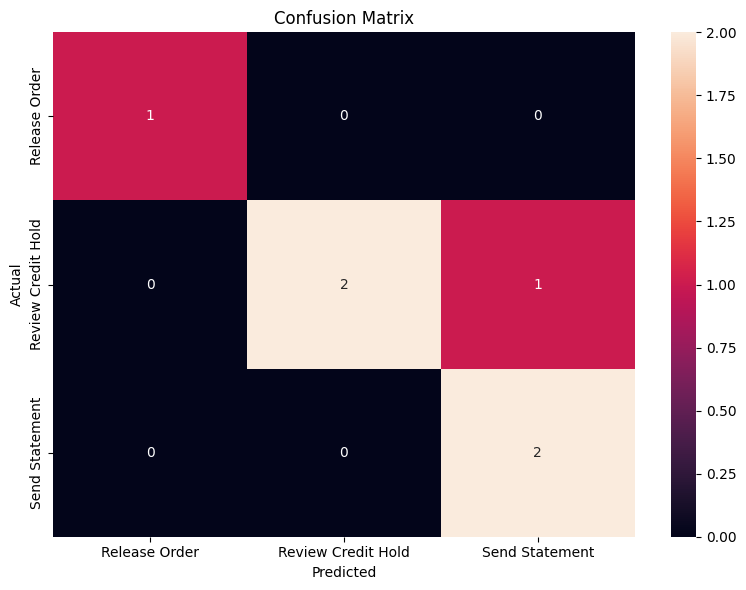

Saved confusion matrix: True


In [76]:
# 7.CONFUSTION MATRIX#

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved confusion matrix:", os.path.exists("confusion_matrix.png"))

                    Feature  Importance
2           Past_Due_Amount    0.376029
10        Customer_Type_OEM    0.343151
0              Total_Orders    0.260809
16             Region_South    0.020012
1       Average_Order_Value    0.000000
3           Current_Balance    0.000000
6              Credit_Score    0.000000
7               Account_Age    0.000000
4   Days_Since_Last_Payment    0.000000
5        Open_Invoice_Count    0.000000


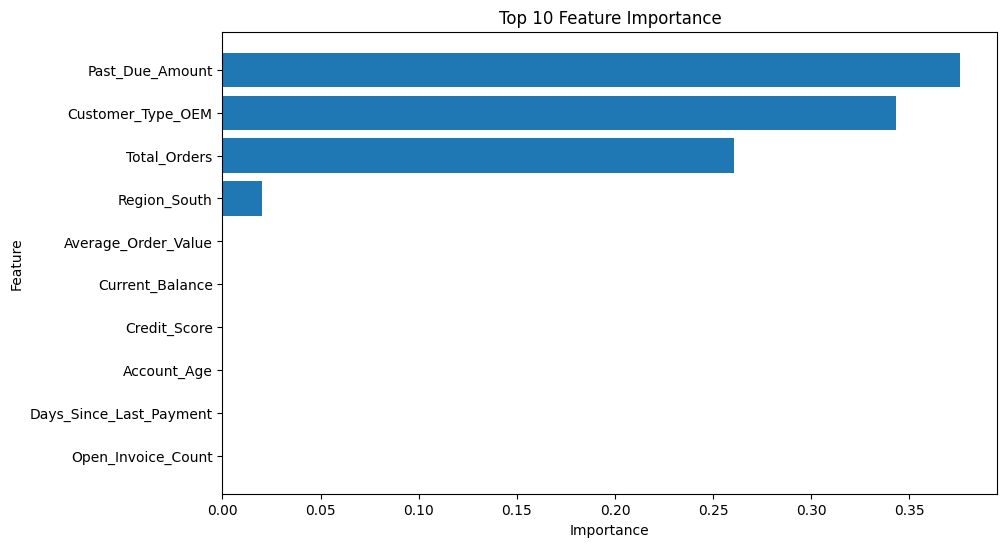

In [83]:
# 8.FEATURE IMPORTANCE#

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(10,6))

plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# 9.NEW CUSTOMER PERDICTIONS#

new_customer = pd.DataFrame([{
    "Total_Orders": 60,
    "Average_Order_Value": 2500,
    "Past_Due_Amount": 30000,
    "Credit_Hold": "Yes",
    "Current_Balance": 70000,
    "Days_Since_Last_Payment": 120,
    "Open_Invoice_Count": 12,
    "Customer_Type": "Distributor",
    "Payment_Terms": "Net60",
    "Credit_Score": 560,
    "Account_Age": 20,
    "Order_Frequency": "Weekly",
    "Region": "Midwest"
}])
new_customer = pd.get_dummies(new_customer)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_customer)
recommended_action = label_encoder.inverse_transform(prediction)

print("Recommended Action:", recommended_action[0])
probabilities = model.predict_proba(new_customer)[0]

print("\nConfidence Levels:")

for label, prob in zip(label_encoder.classes_, probabilities):
    print(f"{label}: {prob:.2%}")

Recommended Action: Review Credit Hold

Confidence Levels:
Release Order: 3.00%
Review Credit Hold: 92.92%
Send Statement: 4.08%


In [44]:
# 10.CONFIDENCE LEVELS#

probabilities = model.predict_proba(new_customer)[0]

print("\nConfidence Levels:")
for label, prob in zip(label_encoder.classes_, probabilities):
    print(f"{label}: {prob:.2%}")


Confidence Levels:
Release Order: 3.00%
Review Credit Hold: 92.92%
Send Statement: 4.08%


In [48]:
#11. SHAP EXPLAINER#

import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the new customer
shap_values = explainer(new_customer)

# Show the class order
print(label_encoder.classes_)

['Release Order' 'Review Credit Hold' 'Send Statement']


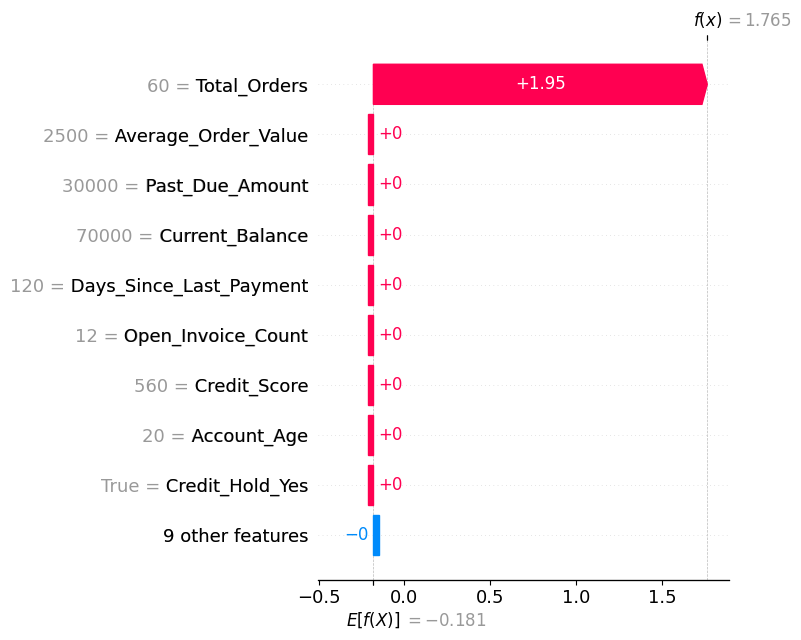

In [84]:
# 12.SHAP WATERFALL PLOT#

# Use the model's prediction automatically
predicted_class = recommended_action[0]

# Find the class index
class_index = list(label_encoder.classes_).index(predicted_class)

# Generate waterfall plot
shap.plots.waterfall(
    shap_values[0, :, class_index],
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# 13.CROSS VALIDATION#
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y_encoded,
    cv=3,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Average accuracy:", cv_scores.mean())

Cross-validation scores: [0.88888889 0.88888889 1.        ]
Average accuracy: 0.9259259259259259


In [53]:
# 14. HYPWEPARAMETER TUNING#
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best accuracy:")
print(grid_search.best_score_)

Best parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Best accuracy:
0.8968253968253969


In [54]:
# 15. USE BEST MODEL#
best_model = grid_search.best_estimator_

predictions = best_model.predict(X_test)

print("Accuracy with best model:", accuracy_score(y_test, predictions))
print(classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
))

Accuracy with best model: 0.8333333333333334
                    precision    recall  f1-score   support

     Release Order       1.00      1.00      1.00         1
Review Credit Hold       1.00      0.67      0.80         3
    Send Statement       0.67      1.00      0.80         2

          accuracy                           0.83         6
         macro avg       0.89      0.89      0.87         6
      weighted avg       0.89      0.83      0.83         6



In [85]:
# 16. REPORT#

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate("Finance_Model_Report.pdf")
styles = getSampleStyleSheet()
story = []

# Title
story.append(Paragraph("Finance Recommendation Model Summary", styles["Title"]))
story.append(Spacer(1, 12))

# Model Metrics
story.append(
    Paragraph(
        f"Cross Validation Accuracy: {cv_scores.mean():.2%}",
        styles["BodyText"]
    )
)

story.append(
    Paragraph(
        f"Best Parameters: {grid_search.best_params_}",
        styles["BodyText"]
    )
)

story.append(
    Paragraph(
        f"Predicted Action: {recommended_action[0]}",
        styles["BodyText"]
    )
)

story.append(Spacer(1, 12))

# Confidence Levels
story.append(Paragraph("Confidence Levels", styles["Heading2"]))

for label, prob in zip(label_encoder.classes_, probabilities):
    story.append(
        Paragraph(
            f"{label}: {prob:.2%}",
            styles["BodyText"]
        )
    )

story.append(Spacer(1, 12))

# Top Features
story.append(Paragraph("Top 10 Features", styles["Heading2"]))

for _, row in importance.head(10).iterrows():
    story.append(
        Paragraph(
            f"{row['Feature']}: {row['Importance']:.4f}",
            styles["BodyText"]
        )
    )

story.append(Spacer(1, 12))

# Feature Importance Graph
story.append(
    Paragraph(
        "Feature Importance Graph",
        styles["Heading2"]
    )
)

story.append(
    Image(
        "feature_importance.png",
        width=450,
        height=275
    )
)

story.append(Spacer(1, 12))

# Confusion Matrix
story.append(
    Paragraph(
        "Confusion Matrix",
        styles["Heading2"]
    )
)

story.append(
    Image(
        "confusion_matrix.png",
        width=400,
        height=300
    )
)

story.append(Spacer(1, 12))

# SHAP Waterfall Plot
story.append(
    Paragraph(
        "SHAP Waterfall Plot",
        styles["Heading2"]
    )
)

story.append(
    Image(
        "shap_waterfall.png",
        width=450,
        height=300
    )
)

doc.build(story)

print("PDF report created successfully.")

PDF report created successfully.


In [86]:
# 17. TEST VALIDATION OF FIGURES

import os

print("Feature Importance:",
      os.path.exists("feature_importance.png"))

print("Confusion Matrix:",
      os.path.exists("confusion_matrix.png"))

print("SHAP Waterfall:",
      os.path.exists("shap_waterfall.png"))

Feature Importance: True
Confusion Matrix: True
SHAP Waterfall: True


In [88]:
# 18. DOWNLOAD PDF

from google.colab import files

files.download("Finance_Model_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>